# Example of Splitting Time Aligned Periodic Frame Power into Uplink and Downlink
This notebook is an example of picking a sensor, day and 10 MHz channel and splitting the cbsd activity into downlink and uplink.

## Imports

In [1]:
import os,sys
sys.path.append(os.path.join(os.getcwd(),"../"))
from nasctn_sea_visualization import *
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates


Importing nasctn_sea_visualization.data_models
It took 1.057818 s to import nasctn_sea_visualization.data_models
Importing nasctn_sea_visualization.plotters


It took 2.25919 s to import nasctn_sea_visualization.plotters
It took 3.317008 s to import all of the active modules


## Data Ingest
Change the path to reflect your local copy  or NIST PDR location (https://data.nist.gov/od/ds/mds2-4214/Raw%20Data/2025-08-14_HU.zip)

In [2]:
day_block_path = r"C:\Users\sandersa\Box\SEA-DATA\Raw Data\2025-08-14_HU.zip"
day_block = DayBlock(file_path = day_block_path)

In [3]:
# Choose the pfp statistic and detector of choice. Mean RMS and Max Peak are the typical choices.
print(day_block.pfp_statistics)
print(day_block.pfp_detectors)

['min', 'max', 'mean']
['rms', 'peak']


In [4]:
# Create a plotter 
day_block_plotter = DayBlockPlotter(day_block)

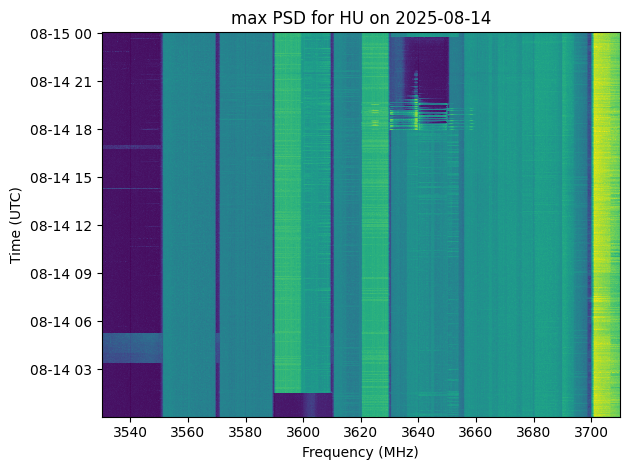

In [5]:
# Plot PSD to Avoid using a band with incumbent activity in it
day_block_plotter.plot_day_psd(capture_statistic = "max")

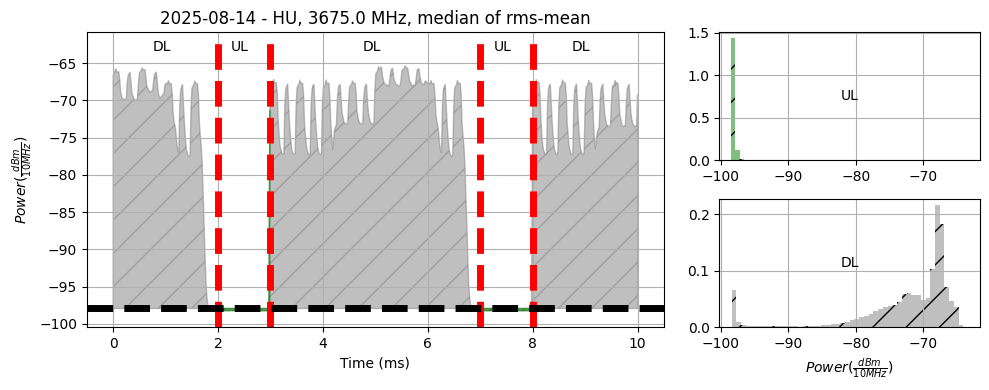

In [6]:
# we choose 3675 MHz
day_block_plotter.plot_day_link_separation(channel = 3675e6)

## Adjust the time slot
the default values in the plotting function are:
```python
        defaults = {"ul1_start_time":2.0,
                    "ul1_stop_time":3.0,
                    "ul2_start_time":7.0,
                    "ul2_stop_time":8.0,
                    "save":False,
                    "show":True}
```


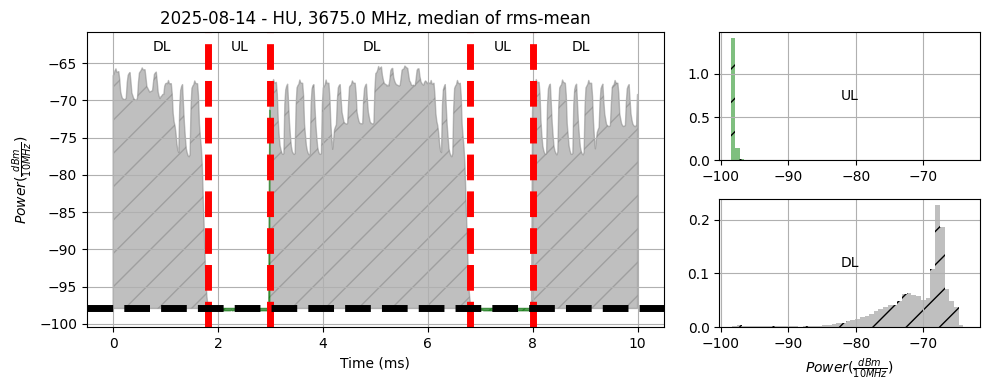

In [7]:
# Here we need to adjust the time slot 
options = {"ul1_start_time":1.8,
                    "ul1_stop_time":3.0,
                    "ul2_start_time":6.8,
                    "ul2_stop_time":8.0,
                    "save":False,
                    "show":True}
day_block_plotter.plot_day_link_separation(channel = 3675e6,**options)

## Check another detector - statistic combination

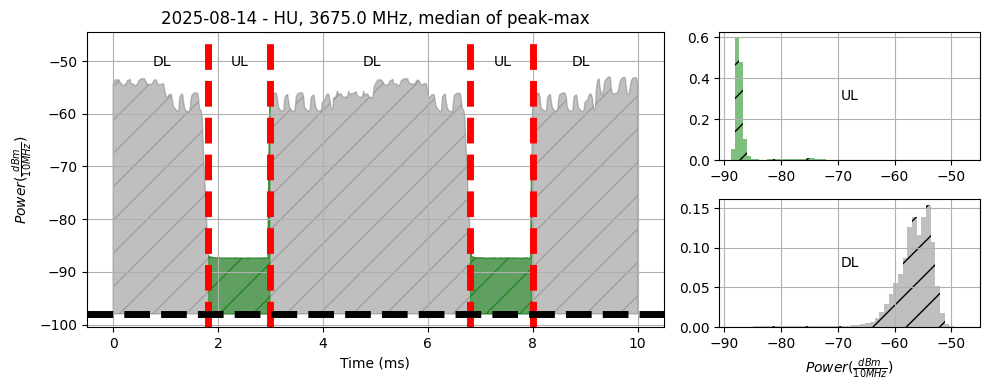

In [8]:
options = {"ul1_start_time":1.8,
                    "ul1_stop_time":3.0,
                    "ul2_start_time":6.8,
                    "ul2_stop_time":8.0,
                    "save":False,
                    "show":True}
day_block_plotter.plot_day_link_separation(channel = 3675e6,capture_statistic='max',detector='peak',**options)

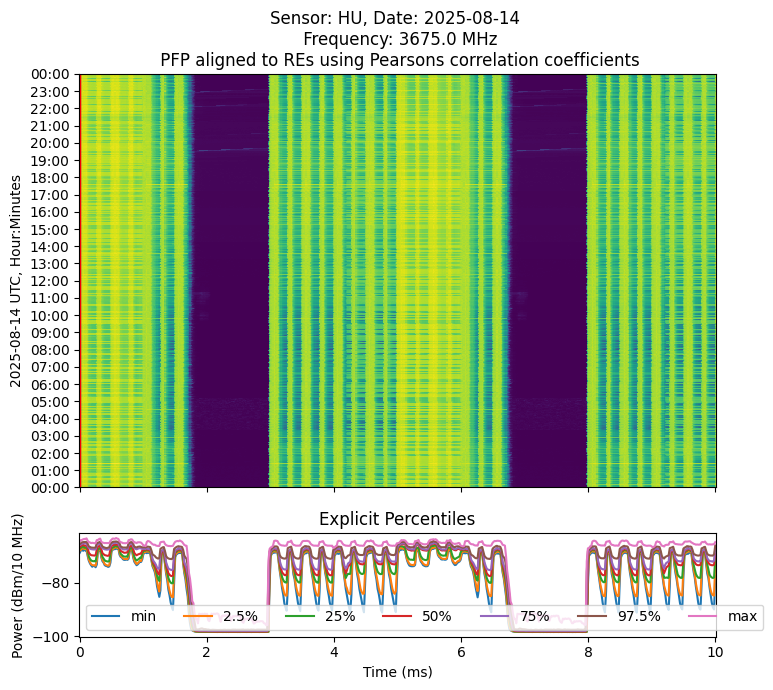

In [9]:
day_block_plotter.plot_aligned_pfp(channel = 3675e6)

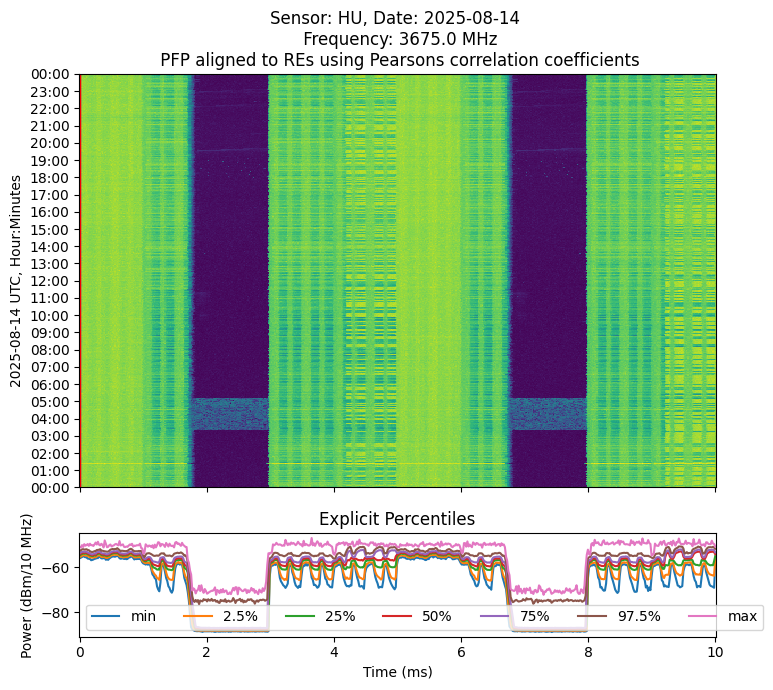

In [10]:
day_block_plotter.plot_aligned_pfp(channel = 3675e6,capture_statistic='max',detector='peak')

## Custom Plot Development
This is an example of taking the plot_day_link_separation method of the DayBlockPlotter class and modifying it to make a comparison panel for the SEA Final Report

In [145]:
# now we create a custom plot that puts it all together
def plot_day_link_separation(day_block,channel,
                                 capture_statistic='mean',detector='rms',**options):
        """Plots the median of the align PFP capture statistic and detector and displays the days statistics seperated by time"""
        defaults = {"ul1_start_time":1.8,
                    "ul1_stop_time":3.0,
                    "ul2_start_time":6.8,
                    "ul2_stop_time":8.0,
                    "save":False,
                    "show":True}
        plot_options = {}
        for key,value in defaults.items():
            plot_options[key] = value
        for key,value in options.items():
            plot_options[key] = value
        if channel in day_block.frequencies:
            frequency = channel
        elif isinstance(channel,int):
            frequency = day_block.frequencies[channel]
        else:
            frequency = float(channel)
        bins = 50
        pfp_ = day_block.get_aligned_pfp(channel=frequency,capture_statistic=capture_statistic,detector=detector)
        median_pfp = np.median(pfp_,axis=0)
        max_pfp = max(pfp_.max())
        x_axis = np.linspace(0,10,len(pfp_.columns))
        ul1_start = np.argmin(abs(x_axis-plot_options["ul1_start_time"]))
        ul1_stop = np.argmin(abs(x_axis-plot_options["ul1_stop_time"]))
        ul2_start = np.argmin(abs(x_axis-plot_options["ul2_start_time"]))
        ul2_stop = np.argmin(abs(x_axis-plot_options["ul2_stop_time"]))
        ul_mask = np.zeros(len(x_axis),dtype=bool)
        for i in range(len(x_axis)):
            if ul1_start<i<ul1_stop or ul2_start<i<ul2_stop:
                ul_mask[i]=True
        
        uplink = pfp_.iloc[:,ul_mask]
        downlink= pfp_.iloc[:,~ul_mask]

        text_y = median_pfp.max()+1
        y_offset_plot = 2.5
        noise_figure_estimate = np.median(day_block.noise_figures[frequency])
        noise_floor_estimate = -174 + 70 + noise_figure_estimate
        # a time axis formatter for better presentation
        date_formatter = mdates.DateFormatter("%H:%M")
        minor_locator = mdates.MinuteLocator(interval = 15)
        major_locator = mdates.HourLocator(interval=3)

        figure = plt.figure(figsize=(8,12))
        gs = matplotlib.gridspec.GridSpec(6,3)
        ax1 = figure.add_subplot(gs[0:4,:])
        ax2 = figure.add_subplot(gs[4, :],sharex=ax1)
        ax3 = figure.add_subplot(gs[5, :])
        x_data = np.linspace(0,10,560)
        colormesh = ax1.pcolormesh(x_data,pfp_.index,pfp_,cmap="bone")
        ax1.set_ylabel("Time (UTC)")
        # ax1.set_xlabel("Periodic Frame Time (ms) ")
        # figure.colorbar(colormesh,ax=ax1,label="dBm/10 MHz")
        ax1.yaxis.set_minor_locator(minor_locator)
        ax1.yaxis.set_major_locator(major_locator)
        ax1.yaxis.set_major_formatter(date_formatter)

        ax2.fill_between(x_axis,median_pfp,noise_floor_estimate,label="Median",hatch='/',color="grey",alpha=.5)
        ax2.fill_between(x_axis[ul_mask],median_pfp[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]< plot_options["ul1_stop_time"]) )
        ax2.fill_between(x_axis[ul_mask],median_pfp[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]> plot_options["ul1_stop_time"]) )
                        

        #plt.plot(x_axis,np.mean(pfp_),label="Mean")
        ax2.axvline(plot_options["ul1_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul1_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul2_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul2_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axhline(noise_floor_estimate,color="k",linewidth=5,linestyle="dashed")
        ax2.text(2.25,text_y,"UL")
        ax2.text(7.25,text_y,"UL")
        ax2.text(.75,text_y,"DL")
        ax2.text(4.75,text_y,"DL")
        ax2.text(8.75,text_y,"DL")
        ax2.set_ylim([noise_floor_estimate-y_offset_plot,max_pfp+y_offset_plot])
        ax2.set_xlabel("Time (ms)")
        ax2.set_ylabel(r"$Power (\frac{dBm}{10 MHz})$")
        # ax2.set_title(f"{day_block.date} - {day_block.sensor}, {frequency*1e-6} MHz, median of {detector}-{capture_statistic}")
        ax2.grid()
        ax3.hist(uplink.values.flatten(),density=True,bins=bins,hatch='/',color="green",alpha=.5,log=False)
        # ax3.text(0.5, 0.5, 'UL', ha='center', va='center', transform=ax2.transAxes)
        # ax3.grid()
        twin_ax3 = ax3.twinx()
        twin_ax3.hist(downlink.values.flatten(),density=True,bins=bins,hatch='/',color="gray",alpha=.5,log = False)
        # ax3.text(0.5, 0.5, 'DL', ha='center', va='center', transform=ax3.transAxes)
        ax3.annotate("", 
            xy=(np.max(downlink.values.flatten()), .5),      # Head position
            xytext=(np.percentile(downlink.values.flatten(),95), .5),  # Tail position
            arrowprops=dict(arrowstyle="->", color="k", lw=3,linestyle="dashed"))
        ax3.annotate("", 
            xy=(-100, .5),      # Head position
            xytext=(np.percentile(uplink.values.flatten(),50), .5),  # Tail position
            arrowprops=dict(arrowstyle="->", color="g", lw=3))
        ax3.grid()
        ax3.set_xlabel(r"$Power (\frac{dBm}{10 MHz})$")
        figure.suptitle(f"{day_block.date} - {day_block.sensor}, {frequency*1e-6} MHz, median of {detector}-{capture_statistic}")
        plt.tight_layout()
        if plot_options["save"]:
            plt.savefig(plot_options["save"])
        if plot_options["show"]:
            plt.show()                 


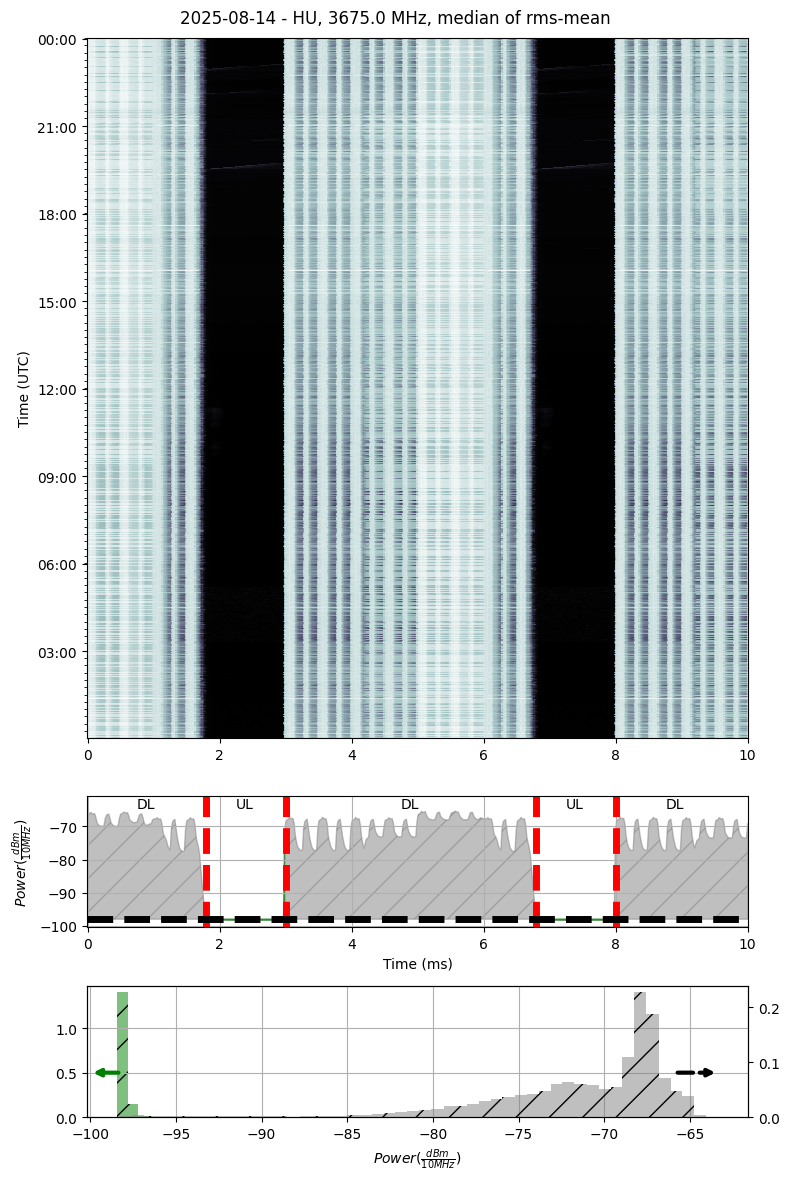

In [146]:
plot_day_link_separation(day_block=day_block,channel = 3675e6,
                                 capture_statistic='mean',detector='rms',**options)

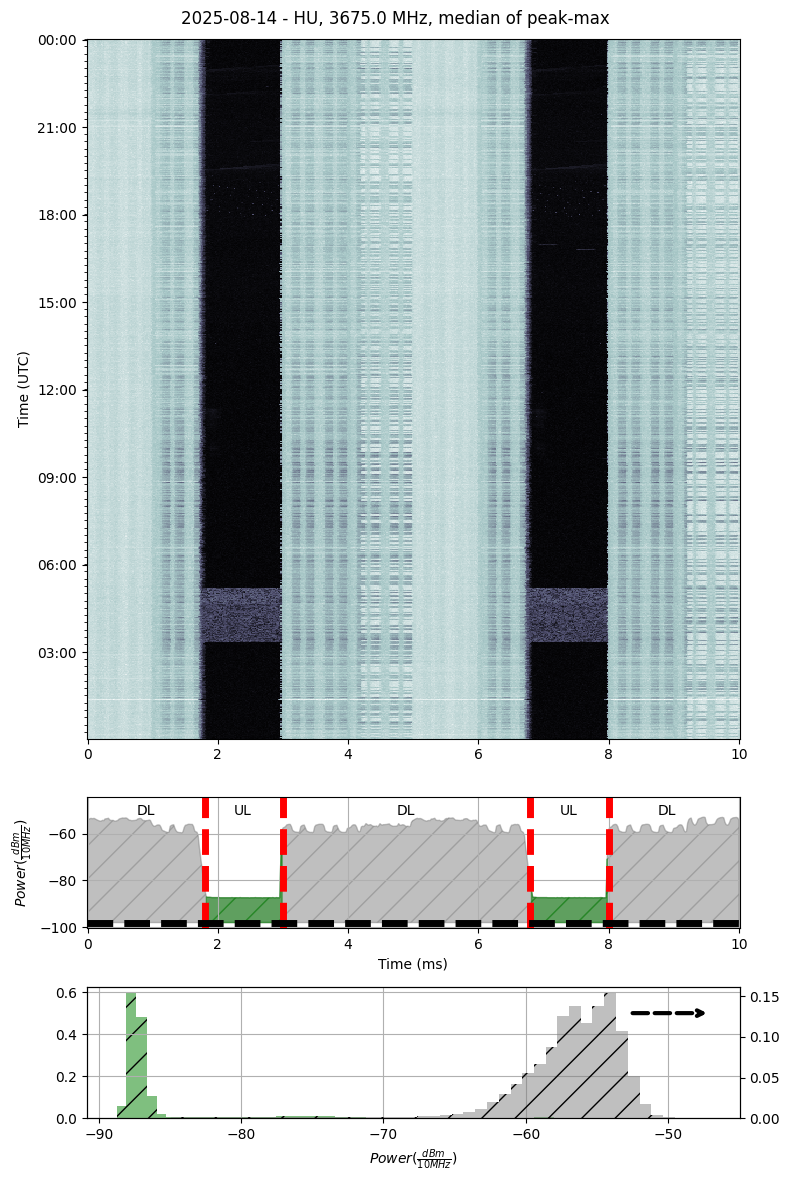

In [147]:
plot_day_link_separation(day_block=day_block,channel = 3675e6,
                                 capture_statistic='max',detector='peak',**options)

In [148]:
# now we create a custom plot that puts it all together
def plot_day_link_separation_comparison(day_block, channel, **options):
        """Plots the median of the align PFP capture statistic and detector and displays the days statistics seperated by time"""
        defaults = {"ul1_start_time":1.8,
                    "ul1_stop_time":3.0,
                    "ul2_start_time":6.8,
                    "ul2_stop_time":8.0,
                    "save":False,
                    "show":True}
        plot_options = {}
        for key,value in defaults.items():
            plot_options[key] = value
        for key,value in options.items():
            plot_options[key] = value
        if channel in day_block.frequencies:
            frequency = channel
        elif isinstance(channel,int):
            frequency = day_block.frequencies[channel]
        else:
            frequency = float(channel)

        detector='rms'
        capture_statistic = 'mean'
        bins = 50
        pfp_ = day_block.get_aligned_pfp(channel=frequency,capture_statistic="mean",detector="rms")
        pfp_2 = day_block.get_aligned_pfp(channel=frequency,capture_statistic="max",detector="peak")

        median_pfp = np.median(pfp_,axis=0)
        max_pfp = max(pfp_.max())
        median_pfp_2 = np.median(pfp_2,axis=0)
        max_pfp_2 = max(pfp_2.max())

        x_axis = np.linspace(0,10,len(pfp_.columns))
        ul1_start = np.argmin(abs(x_axis-plot_options["ul1_start_time"]))
        ul1_stop = np.argmin(abs(x_axis-plot_options["ul1_stop_time"]))
        ul2_start = np.argmin(abs(x_axis-plot_options["ul2_start_time"]))
        ul2_stop = np.argmin(abs(x_axis-plot_options["ul2_stop_time"]))
        ul_mask = np.zeros(len(x_axis),dtype=bool)
        for i in range(len(x_axis)):
            if ul1_start<i<ul1_stop or ul2_start<i<ul2_stop:
                ul_mask[i]=True
        
        uplink = pfp_.iloc[:,ul_mask]
        downlink= pfp_.iloc[:,~ul_mask]
        uplink_2 = pfp_2.iloc[:,ul_mask]
        downlink_2= pfp_2.iloc[:,~ul_mask]
        text_y = median_pfp.max()+1
        y_offset_plot = 2.5
        noise_figure_estimate = np.median(day_block.noise_figures[frequency])
        noise_floor_estimate = -174 + 70 + noise_figure_estimate
        # a time axis formatter for better presentation
        date_formatter = mdates.DateFormatter("%H:%M")
        minor_locator = mdates.MinuteLocator(interval = 15)
        major_locator = mdates.HourLocator(interval=3)

        figure = plt.figure(figsize=(12,12))
        gs = matplotlib.gridspec.GridSpec(6,6)
        ax1 = figure.add_subplot(gs[0:4,0:3])
        ax2 = figure.add_subplot(gs[4, 0:3],sharex=ax1)
        ax3 = figure.add_subplot(gs[5, 0:3])
        ax4 = figure.add_subplot(gs[0:4,3:],sharey=ax1)
        ax5 = figure.add_subplot(gs[4, 3:],sharex=ax4,sharey=ax2)
        ax6 = figure.add_subplot(gs[5, 3:])
        x_data = np.linspace(0,10,560)
        ##################################################
        colormesh = ax1.pcolormesh(x_data,pfp_.index,pfp_,cmap="bone")
        ax1.set_ylabel("Time (UTC)")
        ax1.yaxis.set_minor_locator(minor_locator)
        ax1.yaxis.set_major_locator(major_locator)
        ax1.yaxis.set_major_formatter(date_formatter)
        ax1.set_title("RMS - Mean")
        ############################################
        colormesh = ax4.pcolormesh(x_data,pfp_2.index,pfp_2,cmap="bone")
        ax4.set_title("Peak - Max")

        ax4.set_ylabel("Time (UTC)")
        ax4.yaxis.set_minor_locator(minor_locator)
        ax4.yaxis.set_major_locator(major_locator)
        ax4.yaxis.set_major_formatter(date_formatter)
        ###########################################################
        ax2.fill_between(x_axis,median_pfp,noise_floor_estimate,label="Median",hatch='/',color="grey",alpha=.5)
        ax2.fill_between(x_axis[ul_mask],median_pfp[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]< plot_options["ul1_stop_time"]) )
        ax2.fill_between(x_axis[ul_mask],median_pfp[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]> plot_options["ul1_stop_time"]) )
                        
        ax2.axvline(plot_options["ul1_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul1_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul2_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axvline(plot_options["ul2_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax2.axhline(noise_floor_estimate,color="k",linewidth=5,linestyle="dashed")
        ax2.text(2.25,text_y,"UL")
        ax2.text(7.25,text_y,"UL")
        ax2.text(.75,text_y,"DL")
        ax2.text(4.75,text_y,"DL")
        ax2.text(8.75,text_y,"DL")
        ax2.set_ylim([noise_floor_estimate-y_offset_plot,max_pfp+y_offset_plot])
        ax2.set_xlabel("Time (ms)")
        ax2.set_ylabel(r"$Power (\frac{dBm}{10 MHz})$")
        ax2.grid()
        ###############################################################################################
        ax5.fill_between(x_axis,median_pfp_2,noise_floor_estimate,label="Median",hatch='/',color="grey",alpha=.5)
        ax5.fill_between(x_axis[ul_mask],median_pfp_2[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]< plot_options["ul1_stop_time"]) )
        ax5.fill_between(x_axis[ul_mask],median_pfp_2[ul_mask],noise_floor_estimate,
                        label="Median",hatch='/',color="green",alpha=.5,where =(x_axis[ul_mask]> plot_options["ul1_stop_time"]) )
                        
        ax5.axvline(plot_options["ul1_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax5.axvline(plot_options["ul1_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax5.axvline(plot_options["ul2_start_time"],color="r",linewidth=5,linestyle="dashed")
        ax5.axvline(plot_options["ul2_stop_time"],color="r",linewidth=5,linestyle="dashed")
        ax5.axhline(noise_floor_estimate,color="k",linewidth=5,linestyle="dashed")
        ax5.text(2.25,text_y,"UL")
        ax5.text(7.25,text_y,"UL")
        ax5.text(.75,text_y,"DL")
        ax5.text(4.75,text_y,"DL")
        ax5.text(8.75,text_y,"DL")
        ax5.set_ylim([noise_floor_estimate-y_offset_plot,max_pfp_2+y_offset_plot])
        ax5.set_xlabel("Time (ms)")
        ax5.set_ylabel(r"$Power (\frac{dBm}{10 MHz})$")

        ax5.grid()
        #######################################################################

        ax3.hist(uplink.values.flatten(),density=True,bins=bins,hatch='/',color="green",alpha=.5,log=False)
        # ax3.text(0.5, 0.5, 'UL', ha='center', va='center', transform=ax2.transAxes)
        # ax3.grid()
        twin_ax3 = ax3.twinx()
        twin_ax3.hist(downlink.values.flatten(),density=True,bins=bins,hatch='/',color="gray",alpha=.5,log = False)
        twin_ax3.set_ylabel("Density (DL)")
        # ax3.text(0.5, 0.5, 'DL', ha='center', va='center', transform=ax3.transAxes)
        ax3.annotate("", 
            xy=(np.max(downlink.values.flatten()), .5),      # Head position
            xytext=(np.percentile(downlink.values.flatten(),95), .5),  # Tail position
            arrowprops=dict(arrowstyle="->", color="k", lw=3,linestyle="dashed"))
        # ax3.annotate("", 
        #     xy=(-100, .5),      # Head position
        #     xytext=(np.percentile(uplink.values.flatten(),50), .5),  # Tail position
        #     arrowprops=dict(arrowstyle="->", color="g", lw=3))
        ax3.grid()
        ax3.set_xlabel(r"$Power (\frac{dBm}{10 MHz})$")
        ax3.set_ylabel("Density (UL)",color='g')

        ax6.hist(uplink_2.values.flatten(),density=True,bins=bins,hatch='/',color="green",alpha=.5,log=False)
        ax6.set_ylabel("Density (UL)",color='g')
        # ax3.text(0.5, 0.5, 'UL', ha='center', va='center', transform=ax2.transAxes)
        # ax3.grid()
        twin_ax6 = ax6.twinx()
        twin_ax6.hist(downlink_2.values.flatten(),density=True,bins=bins,hatch='/',color="gray",alpha=.5,log = False)
        twin_ax6.set_ylabel("Density (DL)")

        # ax3.text(0.5, 0.5, 'DL', ha='center', va='center', transform=ax3.transAxes)
        ax6.annotate("", 
            xy=(np.max(downlink_2.values.flatten()), .5),      # Head position
            xytext=(np.percentile(downlink_2.values.flatten(),95), .5),  # Tail position
            arrowprops=dict(arrowstyle="->", color="k", lw=3,linestyle="dashed"))
        # ax3.annotate("", 
        #     xy=(-100, .5),      # Head position
        #     xytext=(np.percentile(uplink.values.flatten(),50), .5),  # Tail position
        #     arrowprops=dict(arrowstyle="->", color="g", lw=3))
        ax6.grid()
        ax6.set_xlabel(r"$Power (\frac{dBm}{10 MHz})$")
        figure.suptitle(f"{day_block.date} - {day_block.sensor}, {frequency*1e-6} MHz, Comparison of RMS-Mean to Peak-Max")
        plt.tight_layout()
        if plot_options["save"]:
            plt.savefig(plot_options["save"])
        if plot_options["show"]:
            plt.show()                 


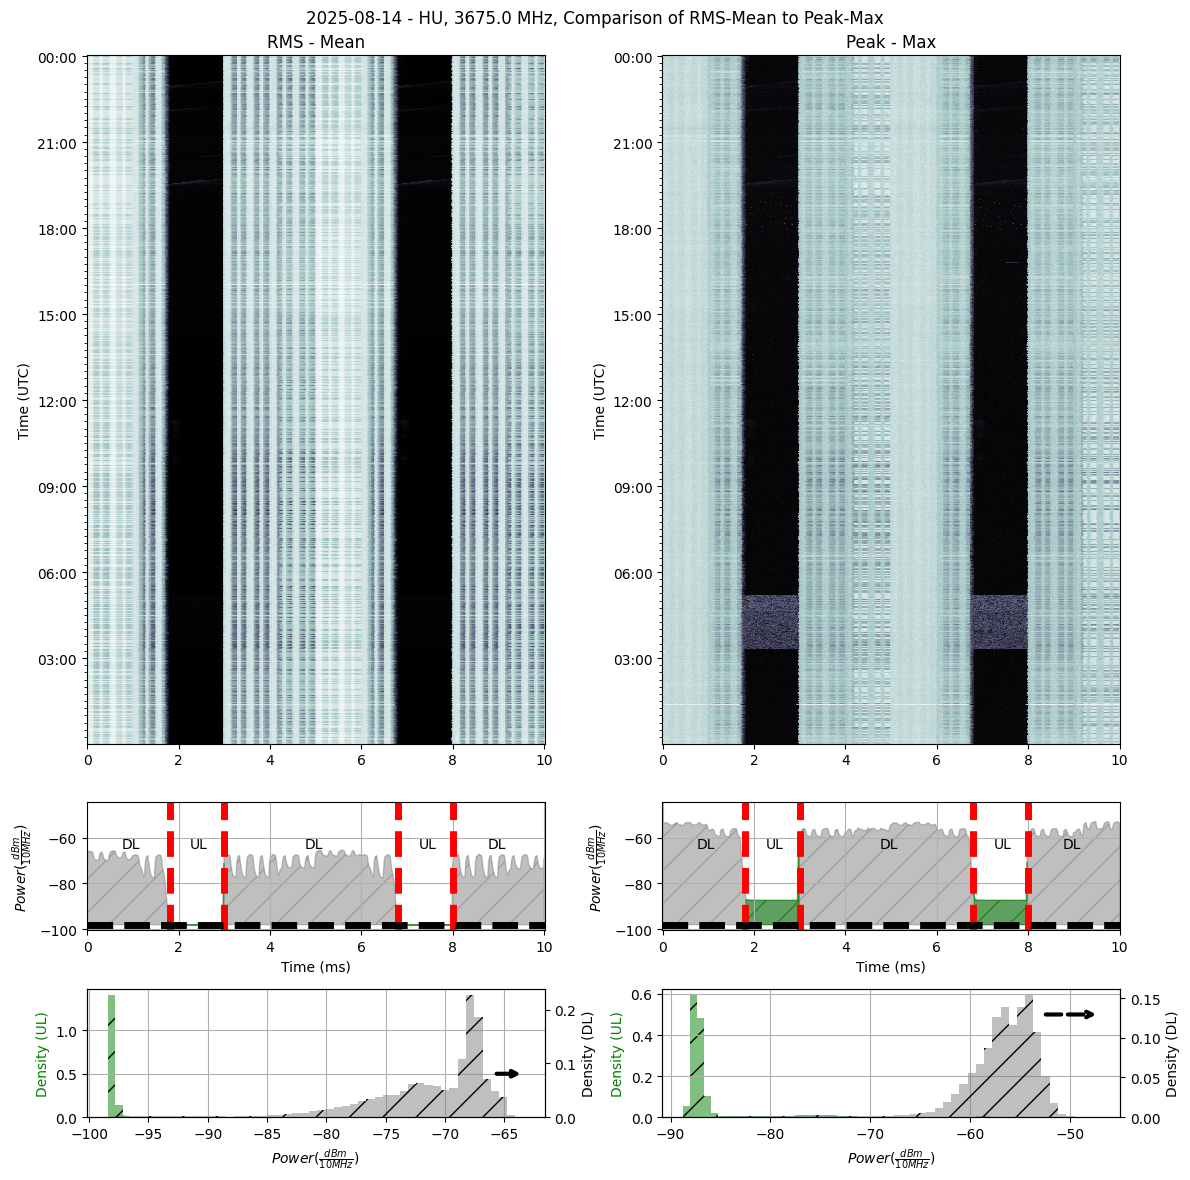

In [149]:
plot_day_link_separation_comparison(day_block=day_block,channel = 3675e6,
                                 **options)

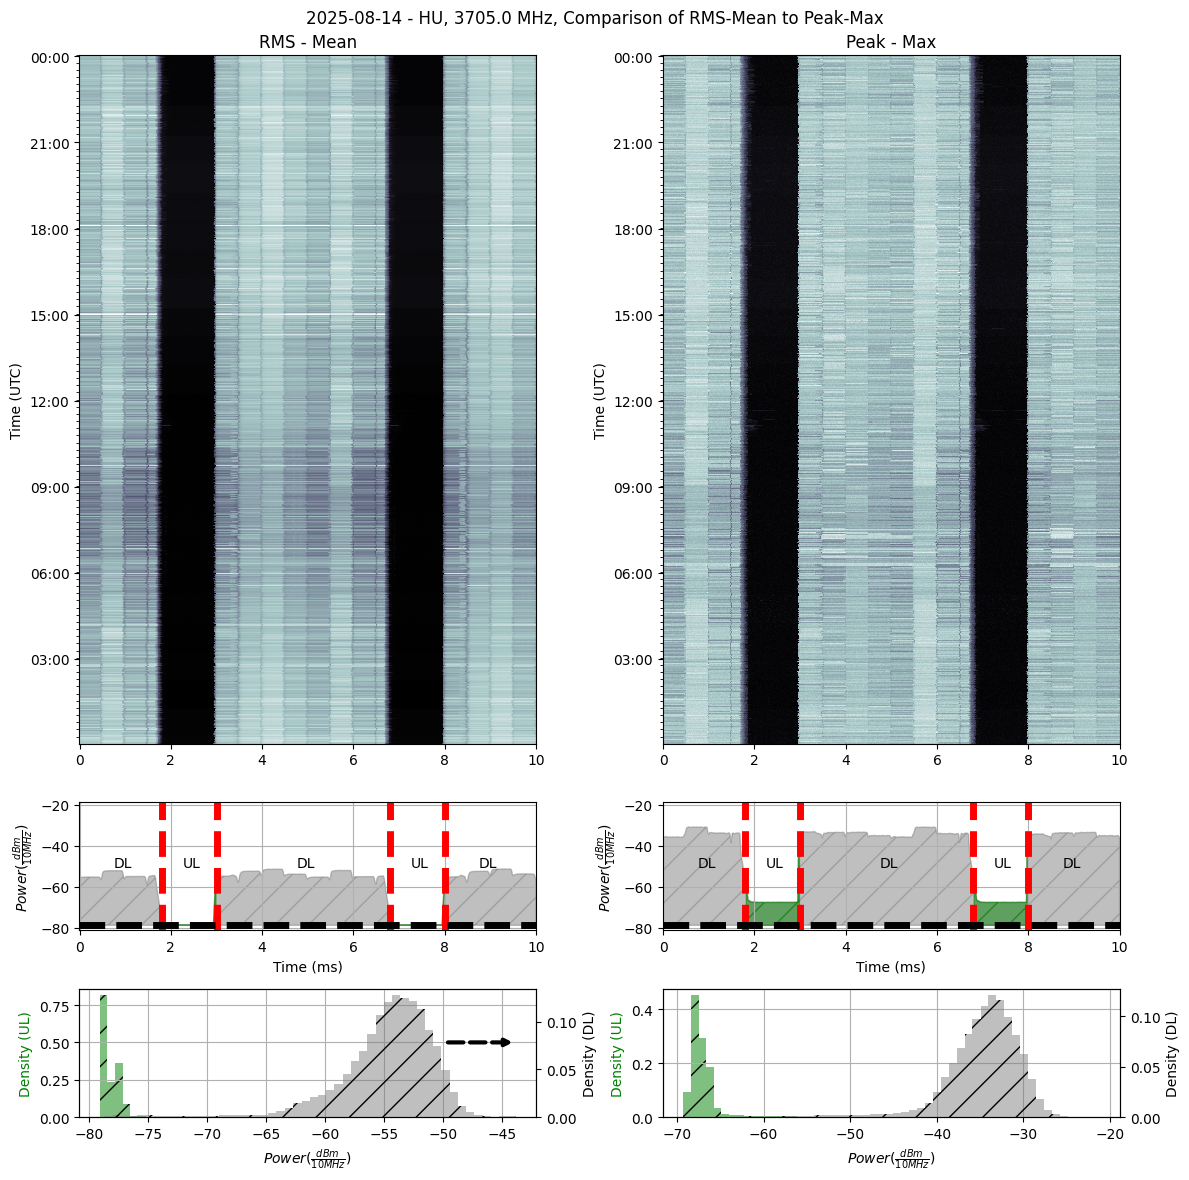

In [150]:
plot_day_link_separation_comparison(day_block=day_block,channel = 3705e6,
                                 **options)

# Watermark

In [11]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2026-09-20T14:03:17.652910-06:00

Python implementation: CPython
Python version       : 3.9.23
IPython version      : 8.18.1

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 197 Stepping 2, GenuineIntel
CPU cores   : 16
Architecture: 64bit

dateutil                : 2.9.0.post0
hvplot                  : 0.8.0
json                    : 2.0.9
matplotlib              : 3.9.4
nasctn_sea_visualization: 0.1.8
numpy                   : 1.26.4
pandas                  : 1.5.3
re                      : 2.2.1
scipy                   : 1.11.0
sea_ingest              : 1.0.1
seaborn                 : 0.12.0

